In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

RANDOM_STATE = 42

print("Classification libraries imported successfully!")

Classification libraries imported successfully!


In [2]:
df = pd.read_csv("../data/processed/f1_master_dataset_final.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (6911, 35)


,season,round,race_name,date,driver_id,driver_code,driver_name,constructor_id,constructor,number,...,avg_finish_last_5,avg_qualifying_last_5,season_points_so_far,season_wins_so_far,season_podiums_so_far,constructor_points_so_far,constructor_wins_so_far,constructor_podiums_so_far,career_races_before,podium
0,2010,1,Bahrain Grand Prix,2010-03-14,alguersuari,ALG,Jaime Alguersuari,toro_rosso,Toro Rosso,17,...,20.0,20.0,0.0,0,0,0.0,0,0,0,0
1,2010,1,Bahrain Grand Prix,2010-03-14,alonso,ALO,Fernando Alonso,ferrari,Ferrari,8,...,20.0,20.0,0.0,0,0,0.0,0,0,0,1
2,2010,1,Bahrain Grand Prix,2010-03-14,barrichello,BAR,Rubens Barrichello,williams,Williams,9,...,20.0,20.0,0.0,0,0,0.0,0,0,0,0
3,2010,1,Bahrain Grand Prix,2010-03-14,bruno_senna,SEN,Bruno Senna,hrt,HRT,21,...,20.0,20.0,0.0,0,0,0.0,0,0,0,0
4,2010,1,Bahrain Grand Prix,2010-03-14,buemi,BUE,Sébastien Buemi,toro_rosso,Toro Rosso,16,...,20.0,20.0,0.0,0,0,0.0,0,0,0,0


In [3]:
feature_columns = [
    "qualifying_position",
    "grid",
    "previous_finish",
    "avg_finish_all_previous",
    "avg_qualifying_all_previous",
    "avg_finish_last_5",
    "avg_qualifying_last_5",
    "season_points_so_far",
    "season_wins_so_far",
    "season_podiums_so_far",
    "constructor_points_so_far",
    "constructor_wins_so_far",
    "constructor_podiums_so_far",
    "career_races_before"
]

X = df[feature_columns].copy()
y = df["podium"].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

print("\nClass percentages:")
print(y.value_counts(normalize=True).mul(100).round(2))

Features shape: (6911, 14)
Target shape: (6911,)

Class distribution:
podium
0    5924
1     987
Name: count, dtype: int64

Class percentages:
podium
0    85.72
1    14.28
Name: proportion, dtype: float64


In [4]:
train_mask = df["season"].between(2010, 2023)
validation_mask = df["season"] == 2024
test_mask = df["season"] == 2025

X_train = df.loc[train_mask, feature_columns].copy()
X_validation = df.loc[validation_mask, feature_columns].copy()
X_test = df.loc[test_mask, feature_columns].copy()

y_train = df.loc[train_mask, "podium"].copy()
y_validation = df.loc[validation_mask, "podium"].copy()
y_test = df.loc[test_mask, "podium"].copy()

print("Training:", X_train.shape)
print("Validation:", X_validation.shape)
print("Testing:", X_test.shape)

Training: (5953, 14)
Validation: (479, 14)
Testing: (479, 14)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_validation_scaled = scaler.transform(X_validation)

X_test_scaled = scaler.transform(X_test)

print("Classification scaling completed!")

Classification scaling completed!


In [6]:
# Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train
logistic_model.fit(X_train_scaled, y_train)

# Predictions
logistic_val_pred = logistic_model.predict(X_validation_scaled)

# Probability of podium
logistic_val_prob = logistic_model.predict_proba(
    X_validation_scaled
)[:, 1]

# Metrics
logistic_accuracy = accuracy_score(
    y_validation, logistic_val_pred
)

logistic_f1 = f1_score(
    y_validation,
    logistic_val_pred,
    average="weighted"
)

logistic_auc = roc_auc_score(
    y_validation,
    logistic_val_prob
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Weighted F1 :", round(logistic_f1, 4))
print("ROC-AUC :", round(logistic_auc, 4))

Logistic Regression
-------------------
Accuracy : 0.8831
Weighted F1 : 0.8786
ROC-AUC : 0.9271


In [7]:
# KNN Classification

knn_classifier = KNeighborsClassifier(
    n_neighbors=5
)

# Train
knn_classifier.fit(X_train_scaled, y_train)

# Predictions
knn_val_pred = knn_classifier.predict(X_validation_scaled)

# Probability of podium
knn_val_prob = knn_classifier.predict_proba(
    X_validation_scaled
)[:, 1]

# Metrics
knn_classifier_accuracy = accuracy_score(
    y_validation, knn_val_pred
)

knn_classifier_f1 = f1_score(
    y_validation,
    knn_val_pred,
    average="weighted"
)

knn_classifier_auc = roc_auc_score(
    y_validation,
    knn_val_prob
)

print("KNN Classification")
print("------------------")
print("Accuracy :", round(knn_classifier_accuracy, 4))
print("Weighted F1 :", round(knn_classifier_f1, 4))
print("ROC-AUC :", round(knn_classifier_auc, 4))

KNN Classification
------------------
Accuracy : 0.8643
Weighted F1 : 0.8682
ROC-AUC : 0.8869


In [8]:
# Gaussian Naive Bayes

nb_model = GaussianNB()

# Train
nb_model.fit(X_train, y_train)

# Predictions
nb_val_pred = nb_model.predict(X_validation)

# Probability of podium
nb_val_prob = nb_model.predict_proba(
    X_validation
)[:, 1]

# Metrics
nb_accuracy = accuracy_score(
    y_validation, nb_val_pred
)

nb_f1 = f1_score(
    y_validation,
    nb_val_pred,
    average="weighted"
)

nb_auc = roc_auc_score(
    y_validation,
    nb_val_prob
)

print("Gaussian Naive Bayes")
print("--------------------")
print("Accuracy :", round(nb_accuracy, 4))
print("Weighted F1 :", round(nb_f1, 4))
print("ROC-AUC :", round(nb_auc, 4))

Gaussian Naive Bayes
--------------------
Accuracy : 0.8058
Weighted F1 : 0.8286
ROC-AUC : 0.8826


In [9]:
# Decision Tree Classification

decision_tree_classifier = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

# Train
decision_tree_classifier.fit(X_train, y_train)

# Predictions
dt_val_pred = decision_tree_classifier.predict(X_validation)

# Probability of podium
dt_val_prob = decision_tree_classifier.predict_proba(
    X_validation
)[:, 1]

# Metrics
dt_accuracy = accuracy_score(
    y_validation, dt_val_pred
)

dt_f1 = f1_score(
    y_validation,
    dt_val_pred,
    average="weighted"
)

dt_auc = roc_auc_score(
    y_validation,
    dt_val_prob
)

print("Decision Tree Classification")
print("----------------------------")
print("Accuracy :", round(dt_accuracy, 4))
print("Weighted F1 :", round(dt_f1, 4))
print("ROC-AUC :", round(dt_auc, 4))

Decision Tree Classification
----------------------------
Accuracy : 0.8539
Weighted F1 : 0.8577
ROC-AUC : 0.7425


In [10]:
# Support Vector Classifier (SVC)

svc_model = SVC(
    kernel="rbf",
    C=1.0,
    probability=True,
    random_state=RANDOM_STATE
)

# Train
svc_model.fit(X_train_scaled, y_train)

# Predictions
svc_val_pred = svc_model.predict(X_validation_scaled)

# Probability of podium
svc_val_prob = svc_model.predict_proba(
    X_validation_scaled
)[:, 1]

# Metrics
svc_accuracy = accuracy_score(
    y_validation, svc_val_pred
)

svc_f1 = f1_score(
    y_validation,
    svc_val_pred,
    average="weighted"
)

svc_auc = roc_auc_score(
    y_validation,
    svc_val_prob
)

print("Support Vector Classifier (SVC)")
print("--------------------------------")
print("Accuracy :", round(svc_accuracy, 4))
print("Weighted F1 :", round(svc_f1, 4))
print("ROC-AUC :", round(svc_auc, 4))

c:\Users\Somesh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Support Vector Classifier (SVC)
--------------------------------
Accuracy : 0.8831
Weighted F1 : 0.881
ROC-AUC : 0.9028


In [11]:
# Classification Model Comparison

classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Gaussian Naive Bayes",
        "Decision Tree",
        "SVC"
    ],
    
    "Accuracy": [
        logistic_accuracy,
        knn_classifier_accuracy,
        nb_accuracy,
        dt_accuracy,
        svc_accuracy
    ],
    
    "Weighted F1": [
        logistic_f1,
        knn_classifier_f1,
        nb_f1,
        dt_f1,
        svc_f1
    ],
    
    "ROC-AUC": [
        logistic_auc,
        knn_classifier_auc,
        nb_auc,
        dt_auc,
        svc_auc
    ]
})

classification_results = classification_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(classification_results.round(4))

,Model,Accuracy,Weighted F1,ROC-AUC
0,Logistic Regression,0.8831,0.8786,0.9271
1,SVC,0.8831,0.8810,0.9028
2,KNN,0.8643,0.8682,0.8869
3,Gaussian Naive Bayes,0.8058,0.8286,0.8826
4,Decision Tree,0.8539,0.8577,0.7425


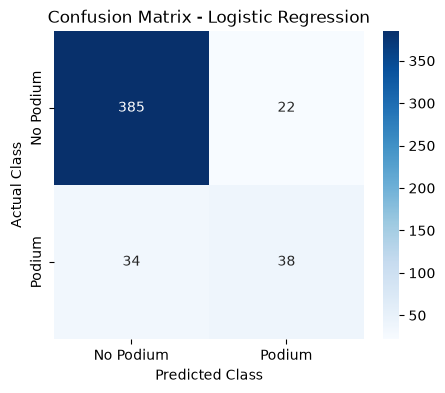

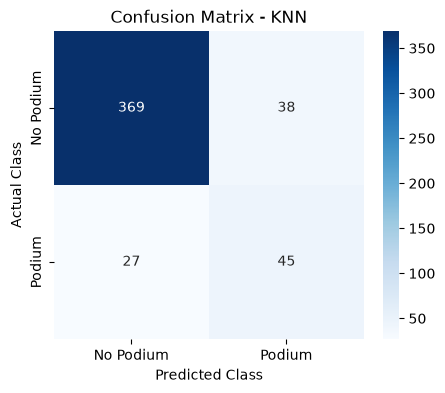

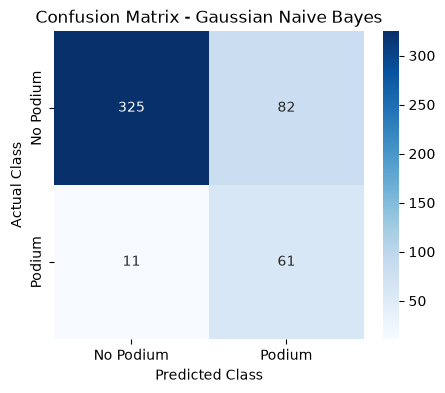

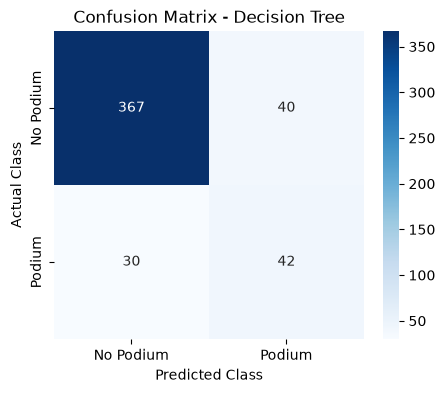

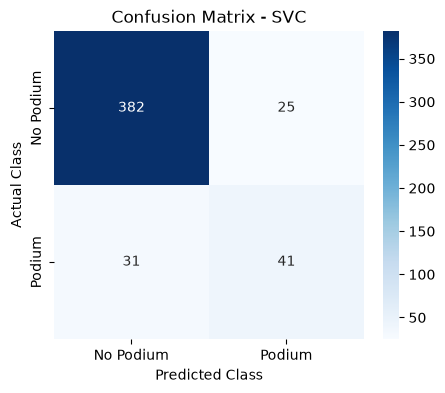

In [12]:
# Confusion Matrices for All 5 Classification Models

models_predictions = {
    "Logistic Regression": logistic_val_pred,
    "KNN": knn_val_pred,
    "Gaussian Naive Bayes": nb_val_pred,
    "Decision Tree": dt_val_pred,
    "SVC": svc_val_pred
}

for model_name, predictions in models_predictions.items():
    
    cm = confusion_matrix(y_validation, predictions)
    
    plt.figure(figsize=(5, 4))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Podium", "Podium"],
        yticklabels=["No Podium", "Podium"]
    )
    
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"Confusion Matrix - {model_name}")
    
    plt.show()

In [13]:
# Save classification comparison results

classification_results.to_csv(
    "../data/processed/classification_model_comparison.csv",
    index=False
)

print("Classification results saved successfully!")

Classification results saved successfully!


In [14]:
# Final Classification Evaluation on 2025 Test Data

# Predictions on 2025
logistic_test_pred = logistic_model.predict(X_test_scaled)
knn_test_pred = knn_classifier.predict(X_test_scaled)
nb_test_pred = nb_model.predict(X_test)
dt_test_pred = decision_tree_classifier.predict(X_test)
svc_test_pred = svc_model.predict(X_test_scaled)

# Probabilities for ROC-AUC
logistic_test_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]
knn_test_prob = knn_classifier.predict_proba(X_test_scaled)[:, 1]
nb_test_prob = nb_model.predict_proba(X_test)[:, 1]
dt_test_prob = decision_tree_classifier.predict_proba(X_test)[:, 1]
svc_test_prob = svc_model.predict_proba(X_test_scaled)[:, 1]

# Store results
final_classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Gaussian Naive Bayes",
        "Decision Tree",
        "SVC"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, logistic_test_pred),
        accuracy_score(y_test, knn_test_pred),
        accuracy_score(y_test, nb_test_pred),
        accuracy_score(y_test, dt_test_pred),
        accuracy_score(y_test, svc_test_pred)
    ],
    
    "Weighted F1": [
        f1_score(y_test, logistic_test_pred, average="weighted"),
        f1_score(y_test, knn_test_pred, average="weighted"),
        f1_score(y_test, nb_test_pred, average="weighted"),
        f1_score(y_test, dt_test_pred, average="weighted"),
        f1_score(y_test, svc_test_pred, average="weighted")
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, logistic_test_prob),
        roc_auc_score(y_test, knn_test_prob),
        roc_auc_score(y_test, nb_test_prob),
        roc_auc_score(y_test, dt_test_prob),
        roc_auc_score(y_test, svc_test_prob)
    ]
})

display(final_classification_results.round(4))

,Model,Accuracy,Weighted F1,ROC-AUC
0,Logistic Regression,0.9269,0.9263,0.9411
1,KNN,0.8643,0.8694,0.8920
2,Gaussian Naive Bayes,0.8601,0.8727,0.9183
3,Decision Tree,0.8810,0.8820,0.7756
4,SVC,0.9186,0.9193,0.9308
